# Notebook 01 : Dataset Exploration

This is the starting point of the whole pipeline. Before training anything, the first step is to understand what data is available and decide which subjects will be used for training and which will be held out as the non-member ground truth for the attack.

The work is grounded in the continual gait identification system from Milani (*"Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification"*, IEEE WIFS 2024), which uses the whuGAIT dataset (Zou et al., 2020). That paper trains on all 118 subjects split across four incremental tasks. Here the evaluation simplifies to a static two-way split, which is enough to study the membership inference signal without adding the complexity of continual learning on top:

| Role | Subject IDs | Count | Dataset |
|---|---|---|---|
| Members (training) | 21-118 | 98 | Dataset #1 (D1) |
| Non-members (held-out) | 1-20 | 20 | Dataset #2 (D2) |

The 98 training subjects go into the CNN encoder (NB02). The 20 held-out subjects are never touched during any training step: they are the non-member ground truth for the attack in NB04 and NB05.

The three datasets used across the pipeline are:

| Dataset | Windows (train) | Windows (test) | Subjects | Role |
|---|---|---|---|---|
| D1 | 33,104 | 3,740 | 118 | CNN encoder training |
| D2 | 44,339 | 4,936 | 20 (IDs 1-20) | Non-member pool |
| D5 | 66,542 pairs | 7,600 pairs | Members + Non-members | Authenticator training and attack signal |

Each window has shape `(6, 128)`: 6 IMU channels (3-axis accelerometer + 3-axis gyroscope) at 100 Hz, giving about 1.28 seconds of gait per window.

The main output is `logs/subject_split.json`, which every subsequent notebook loads to keep the member/non-member split consistent throughout.

## Pipeline overview

```
Dataset #1 (D1)  ─── IDs 21–118 ──►  Members (98 subjects)   ─► NB02 CNN training
  118 subjects   └── IDs  1–20  ──►  Non-members (20 subjects) ─► NB04/05 attack

Dataset #2 (D2)  ─── IDs  1–20  ──►  Non-member probe data    ─► NB04/05 delta scores
  20 subjects

Dataset #5 (D5)  ─────────────────►  Authenticated pairs       ─► NB03 LSTM training
  pair format                         (same / different)          NB04/05 delta signal
  (6, 256) → split at 128 → X1, X2
```

The split saved at the end of this notebook (`logs/subject_split.json`) is loaded by every subsequent notebook as the single source of truth.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.data.dataset import load_dataset, filter_subjects

# ── paths ──
DATA_ROOT  = Path('../data')
LOG_DIR    = Path('../logs')
RESULT_DIR = Path('../results')
LOG_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

# ── logging ──
log = logging.getLogger('nb01')
log.setLevel(logging.DEBUG)
log.handlers.clear()
fh = logging.FileHandler(LOG_DIR / '01_explore.log', mode='w')
fh.setFormatter(logging.Formatter('%(asctime)s  %(message)s', datefmt='%H:%M:%S'))
sh = logging.StreamHandler()
sh.setFormatter(logging.Formatter('%(message)s'))
log.addHandler(fh)
log.addHandler(sh)

log.info('=== Notebook 01 — Dataset Exploration ===')

=== Notebook 01 — Dataset Exploration ===


## 1. Load Dataset #1

D1 contains all 118 subjects. All 118 subjects are loaded here but only IDs 21-118 are used for CNN training: the first 20 subjects overlap with D2 and are reserved as non-members.

In [2]:
D1_ROOT = DATA_ROOT / 'Dataset #1'

X_d1_train, y_d1_train = load_dataset(str(D1_ROOT), 'train')
X_d1_test,  y_d1_test  = load_dataset(str(D1_ROOT), 'test')

d1_subjects = sorted(np.unique(np.concatenate([y_d1_train, y_d1_test])).tolist())

log.info(f'Dataset #1  train: {len(y_d1_train)} windows')
log.info(f'Dataset #1  test:  {len(y_d1_test)} windows')
log.info(f'Dataset #1  subjects: {len(d1_subjects)}  IDs {min(d1_subjects)}..{max(d1_subjects)}')
log.info(f'Dataset #1  X shape: {X_d1_train.shape}  dtype: {X_d1_train.dtype}')
print(f'Dataset #1: {len(y_d1_train)} train + {len(y_d1_test)} test windows, {len(d1_subjects)} subjects')

Dataset #1  train: 33104 windows
Dataset #1  test:  3740 windows
Dataset #1  subjects: 118  IDs 1..118
Dataset #1  X shape: (33104, 6, 128)  dtype: float32


Dataset #1: 33104 train + 3740 test windows, 118 subjects


## 2. Load Dataset #2

D2 contains the 20 non-member subjects (IDs 1-20). These were recorded in a different session from D1, which matters: when we query non-members in NB04, the probe data comes from a different day than anything seen during training. This makes the attack more realistic but also introduces a session confound that NB04 addresses with a controlled experiment.

In [3]:
D2_ROOT = DATA_ROOT / 'Dataset #2'

X_d2_train, y_d2_train = load_dataset(str(D2_ROOT), 'train')
X_d2_test,  y_d2_test  = load_dataset(str(D2_ROOT), 'test')

d2_subjects = sorted(np.unique(np.concatenate([y_d2_train, y_d2_test])).tolist())

log.info(f'Dataset #2  train: {len(y_d2_train)} windows')
log.info(f'Dataset #2  test:  {len(y_d2_test)} windows')
log.info(f'Dataset #2  subjects: {len(d2_subjects)}  IDs {d2_subjects}')
print(f'Dataset #2: {len(y_d2_train)} train + {len(y_d2_test)} test windows, {len(d2_subjects)} subjects')

Dataset #2  train: 44339 windows
Dataset #2  test:  4936 windows
Dataset #2  subjects: 20  IDs [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


Dataset #2: 44339 train + 4936 test windows, 20 subjects


## 3. Identify the Subject Split

Since D2 contains IDs 1-20 and D1 contains all 118, the split follows naturally: D2 subjects are non-members, everyone else in D1 is a member. A sanity check verifies there is no overlap between the two groups before saving.

In [4]:
held_out_ids = sorted(set(d2_subjects))
train_ids    = sorted(set(d1_subjects) - set(held_out_ids))

# ── sanity checks ──
assert len(held_out_ids) == 20, f'Expected 20 held-out, got {len(held_out_ids)}'
assert len(train_ids)    == 98, f'Expected 98 training, got {len(train_ids)}'
assert len(set(held_out_ids) & set(train_ids)) == 0, 'Overlap detected!'

log.info(f'Held-out IDs  (non-members, n=20): {held_out_ids}')
log.info(f'Training IDs  (members,     n=98): {train_ids}')
log.info('All sanity checks passed.')

print(f'Training subjects  (members):     {len(train_ids)}')
print(f'Held-out subjects  (non-members): {len(held_out_ids)}')
print(f'Overlap: none  ✓')

Held-out IDs  (non-members, n=20): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Training IDs  (members,     n=98): [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118]
All sanity checks passed.


Training subjects  (members):     98
Held-out subjects  (non-members): 20
Overlap: none  ✓


## 4. Dataset #5 : Label Balance Check

D5 contains pre-built authentication pairs with a 50/50 same/different balance. This is verified here because the balance matters for the delta score: with equal numbers of same-person and different-person pairs, the delta is a centred signal and a random model would produce a delta close to zero.

In [5]:
D5_ROOT = DATA_ROOT / 'Dataset #5'

y_d5_train = np.loadtxt(D5_ROOT / 'train' / 'y_train.txt', dtype=np.int32)
y_d5_test  = np.loadtxt(D5_ROOT / 'test'  / 'y_test.txt',  dtype=np.int32)

# Labels: 1=different person, 2=same person
d5_train_same = int((y_d5_train == 2).sum())
d5_train_diff = int((y_d5_train == 1).sum())
d5_test_same  = int((y_d5_test  == 2).sum())
d5_test_diff  = int((y_d5_test  == 1).sum())

log.info(f'Dataset #5  train: {len(y_d5_train)} pairs  same={d5_train_same} ({100*d5_train_same/len(y_d5_train):.1f}%)  diff={d5_train_diff}')
log.info(f'Dataset #5  test:  {len(y_d5_test)} pairs   same={d5_test_same}  ({100*d5_test_same/len(y_d5_test):.1f}%)  diff={d5_test_diff}')
log.info(f'Dataset #5  unique label values: {np.unique(y_d5_train).tolist()}')

print(f'Dataset #5 train: {len(y_d5_train)} pairs — {100*d5_train_same/len(y_d5_train):.1f}% same person')
print(f'Dataset #5 test:  {len(y_d5_test)} pairs  — {100*d5_test_same/len(y_d5_test):.1f}% same person')

Dataset #5  train: 66542 pairs  same=33271 (50.0%)  diff=33271
Dataset #5  test:  7600 pairs   same=3800  (50.0%)  diff=3800
Dataset #5  unique label values: [1, 2]


Dataset #5 train: 66542 pairs — 50.0% same person
Dataset #5 test:  7600 pairs  — 50.0% same person


## 5. Save the Subject Split

The split is saved to `logs/subject_split.json`. This file is the single source of truth for NB02 through NB05. Centralising it means the member/non-member assignment never drifts between notebooks.

In [6]:
split = {
    'train_ids':    train_ids,
    'held_out_ids': held_out_ids,
    'n_train':      len(train_ids),
    'n_held_out':   len(held_out_ids),
}
with open(LOG_DIR / 'subject_split.json', 'w') as f:
    json.dump(split, f, indent=2)

log.info('Subject split saved to logs/subject_split.json')
print('Subject split saved to logs/subject_split.json  ✓')

Subject split saved to logs/subject_split.json


Subject split saved to logs/subject_split.json  ✓


## 6. D5 Pair Attribution

Each D5 pair window is attributed to a subject via a fingerprint: the first 32 values of the window rounded to 1 decimal place. D5 train windows trace back to D1 (members), D5 test windows to D2 (non-members).

Five of the 20 non-member subjects have different IDs in D1 vs D2 (same physical person, different numbering). The D1-nm fallback applies a known remapping `{4→15, 5→16, 6→17, 8→18, 16→19}` before using D1 as a fallback source for D5 test windows not found in D2.

Label convention: raw label 1 = same person → y=0; raw label 2 = different person → y=1.

In [7]:
from src.data.auth_dataset import load_auth_dataset

# ── Fingerprint helpers ──
def window_fingerprint(X):
    return [tuple(np.round(x.flatten()[:32], 1)) for x in X]

def build_lookup(X, y):
    return {k: int(v) for k, v in zip(window_fingerprint(X), y)}

def lookup_arr(keys, lut):
    return np.array([lut.get(k, -1) for k in keys])

# ── Build lookup tables from already-loaded D1 and D2 ──
D1_all   = np.concatenate([X_d1_train, X_d1_test])
y_d1_all = np.concatenate([y_d1_train, y_d1_test])
D2_all   = np.concatenate([X_d2_train, X_d2_test])
y_d2_all = np.concatenate([y_d2_train, y_d2_test])

lut_d1 = build_lookup(D1_all, y_d1_all)
lut_d2 = build_lookup(D2_all, y_d2_all)

# ── D1→D2 ID remapping for non-members ──
# These 5 physical people have different subject IDs in D1 vs D2.
# Derived by finding windows present in both datasets that map to different IDs.
D1_TO_D2 = {4: 15, 5: 16, 6: 17, 8: 18, 16: 19}
lut_d1_nm_fixed = {k: D1_TO_D2.get(int(v), int(v))
                   for k, v in lut_d1.items() if v in set(held_out_ids)}

# ── Load D5 pairs and attribute ──
X1_d5_tr, X2_d5_tr, y_d5_tr = load_auth_dataset(str(DATA_ROOT / 'Dataset #5'), 'train')
X1_d5_te, X2_d5_te, y_d5_te = load_auth_dataset(str(DATA_ROOT / 'Dataset #5'), 'test')

fp1_tr = window_fingerprint(X1_d5_tr); fp2_tr = window_fingerprint(X2_d5_tr)
fp1_te = window_fingerprint(X1_d5_te); fp2_te = window_fingerprint(X2_d5_te)

a1_tr = lookup_arr(fp1_tr, lut_d1);  a2_tr = lookup_arr(fp2_tr, lut_d1)
a1_te = lookup_arr(fp1_te, lut_d2);  a2_te = lookup_arr(fp2_te, lut_d2)

a1_te_fb = lookup_arr(fp1_te, lut_d1_nm_fixed)
a2_te_fb = lookup_arr(fp2_te, lut_d1_nm_fixed)
a1_te[a1_te == -1] = a1_te_fb[a1_te == -1]
a2_te[a2_te == -1] = a2_te_fb[a2_te == -1]

log.info(f'D5 train attribution (X1→D1): {(a1_tr!=-1).mean():.1%}')
log.info(f'D5 test  attribution (X1→D2): {(a1_te!=-1).mean():.1%}')

# ── Sanity check: y=0 same-person pairs → a1==a2; y=1 diff-person → a1!=a2 ──
attr_tr = (a1_tr != -1) & (a2_tr != -1)
attr_te = (a1_te != -1) & (a2_te != -1)

fp_same_ok_tr = (a1_tr[(y_d5_tr==0) & attr_tr] == a2_tr[(y_d5_tr==0) & attr_tr]).mean()
fp_diff_ok_tr = (a1_tr[(y_d5_tr==1) & attr_tr] != a2_tr[(y_d5_tr==1) & attr_tr]).mean()
fp_same_ok_te = (a1_te[(y_d5_te==0) & attr_te] == a2_te[(y_d5_te==0) & attr_te]).mean()
fp_diff_ok_te = (a1_te[(y_d5_te==1) & attr_te] != a2_te[(y_d5_te==1) & attr_te]).mean()

assert fp_same_ok_tr > 0.99, f'Train same-pair mismatch: {fp_same_ok_tr:.1%}'
assert fp_diff_ok_tr > 0.99, f'Train diff-pair mismatch: {fp_diff_ok_tr:.1%}'
assert fp_same_ok_te > 0.99, f'Test  same-pair mismatch: {fp_same_ok_te:.1%}'
assert fp_diff_ok_te > 0.99, f'Test  diff-pair mismatch: {fp_diff_ok_te:.1%}'

log.info('Fingerprint sanity check passed.')

# ── Save ──
np.savez(LOG_DIR / 'd5_attribution.npz',
         a1_tr=a1_tr, a2_tr=a2_tr,
         a1_te=a1_te, a2_te=a2_te)
log.info('D5 attribution saved to logs/d5_attribution.npz')
print(f'D5 train attribution: {(a1_tr!=-1).mean():.1%}  sanity check: {fp_same_ok_tr:.1%}/{fp_diff_ok_tr:.1%}')
print(f'D5 test  attribution: {(a1_te!=-1).mean():.1%}  sanity check: {fp_same_ok_te:.1%}/{fp_diff_ok_te:.1%}')
print('Attribution saved to logs/d5_attribution.npz  ✓')

D5 train attribution (X1→D1): 100.0%
D5 test  attribution (X1→D2): 66.1%
Fingerprint sanity check passed.
D5 attribution saved to logs/d5_attribution.npz


D5 train attribution: 100.0%  sanity check: 100.0%/100.0%
D5 test  attribution: 66.1%  sanity check: 100.0%/100.0%
Attribution saved to logs/d5_attribution.npz  ✓


## 7. Sample Count per Subject : Dataset #1

A quick check on how many windows each subject contributes. Large imbalances could bias CNN training toward subjects with more data.

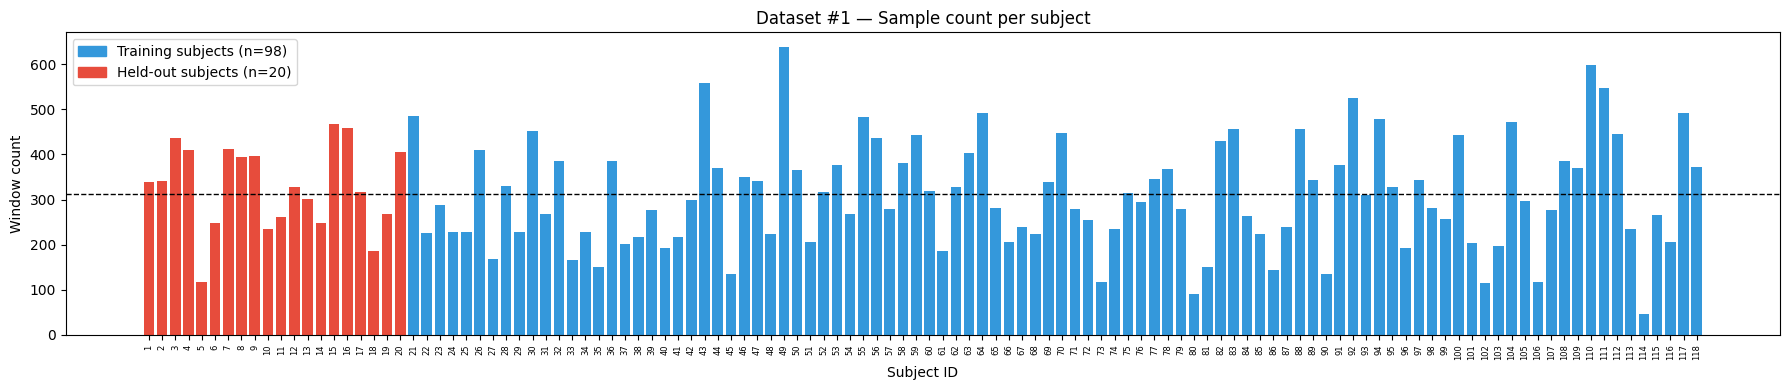

Figure saved: results/01_d1_sample_counts.png
Dataset #1 samples/subject — mean=312  min=47  max=639


In [8]:
y_d1_all = np.concatenate([y_d1_train, y_d1_test])
counts_d1 = {sid: int((y_d1_all == sid).sum()) for sid in d1_subjects}

colors = ['#e74c3c' if sid in held_out_ids else '#3498db' for sid in d1_subjects]

fig, ax = plt.subplots(figsize=(18, 4))
ax.bar(range(len(d1_subjects)), [counts_d1[s] for s in d1_subjects], color=colors, width=0.8)
ax.set_xticks(range(len(d1_subjects)))
ax.set_xticklabels(d1_subjects, fontsize=6, rotation=90)
ax.set_xlabel('Subject ID')
ax.set_ylabel('Window count')
ax.set_title('Dataset #1 — Sample count per subject')
ax.axhline(np.mean(list(counts_d1.values())), color='k', linestyle='--', linewidth=1, label='Mean')
legend_patches = [
    mpatches.Patch(color='#3498db', label=f'Training subjects (n={len(train_ids)})'),
    mpatches.Patch(color='#e74c3c', label=f'Held-out subjects (n={len(held_out_ids)})'),
]
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_d1_sample_counts.png', dpi=150)
plt.show()
log.info(f'Figure saved: results/01_d1_sample_counts.png')
log.info(f'Dataset #1 samples/subject — mean={np.mean(list(counts_d1.values())):.0f}  min={min(counts_d1.values())}  max={max(counts_d1.values())}')

## 8. Sample Count per Subject : Dataset #2

Same check for non-member subjects. D2 tends to have more windows per subject than D1 because it was recorded in a longer session: this is part of why the session confound in NB04 needs its own controlled experiment.

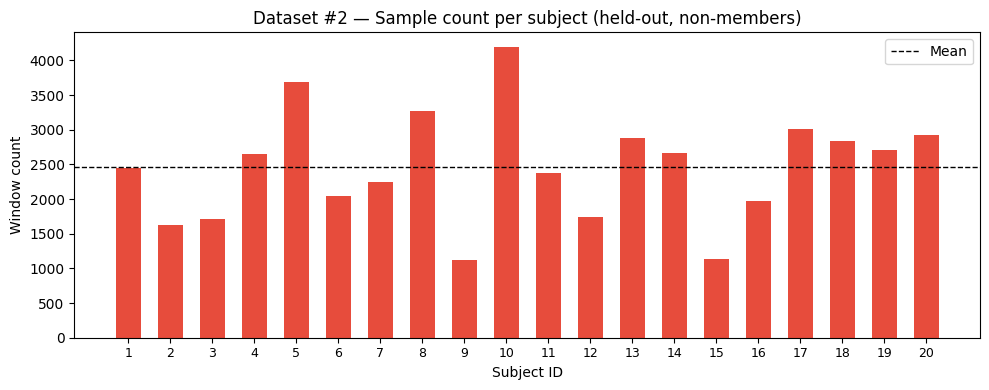

Figure saved: results/01_d2_sample_counts.png
Dataset #2 samples/subject — mean=2464  min=1126  max=4195


In [9]:
y_d2_all = np.concatenate([y_d2_train, y_d2_test])
counts_d2 = {sid: int((y_d2_all == sid).sum()) for sid in d2_subjects}

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(d2_subjects)), [counts_d2[s] for s in d2_subjects], color='#e74c3c', width=0.6)
ax.set_xticks(range(len(d2_subjects)))
ax.set_xticklabels(d2_subjects, fontsize=9)
ax.set_xlabel('Subject ID')
ax.set_ylabel('Window count')
ax.set_title('Dataset #2 — Sample count per subject (held-out, non-members)')
ax.axhline(np.mean(list(counts_d2.values())), color='k', linestyle='--', linewidth=1, label='Mean')
ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_d2_sample_counts.png', dpi=150)
plt.show()
log.info(f'Figure saved: results/01_d2_sample_counts.png')
log.info(f'Dataset #2 samples/subject — mean={np.mean(list(counts_d2.values())):.0f}  min={min(counts_d2.values())}  max={max(counts_d2.values())}')

## 9. Dataset #5 : Same vs Different Pair Balance

Confirming the 50/50 split in D5. With this balance the authentication model trains without class imbalance, and the delta score δ = mean P(same) − mean P(diff) is interpretable as a centred signal.

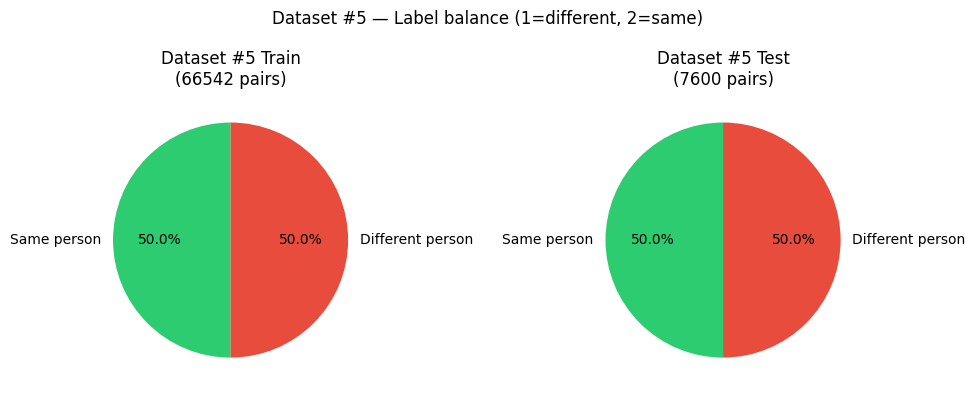

Figure saved: results/01_d5_label_balance.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (same, diff, title) in zip(axes, [
    (d5_train_same, d5_train_diff, f'Dataset #5 Train\n({len(y_d5_train)} pairs)'),
    (d5_test_same,  d5_test_diff,  f'Dataset #5 Test\n({len(y_d5_test)} pairs)'),
]):
    wedges, texts, autotexts = ax.pie(
        [same, diff],
        labels=['Same person', 'Different person'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%',
        startangle=90,
    )
    ax.set_title(title)

plt.suptitle('Dataset #5 — Label balance (1=different, 2=same)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_d5_label_balance.png', dpi=150)
plt.show()
log.info('Figure saved: results/01_d5_label_balance.png')

## 10. Raw Window Visualisation

A sanity check: plot one window across all 6 IMU channels to confirm the data loaded correctly and the signals look like gait.

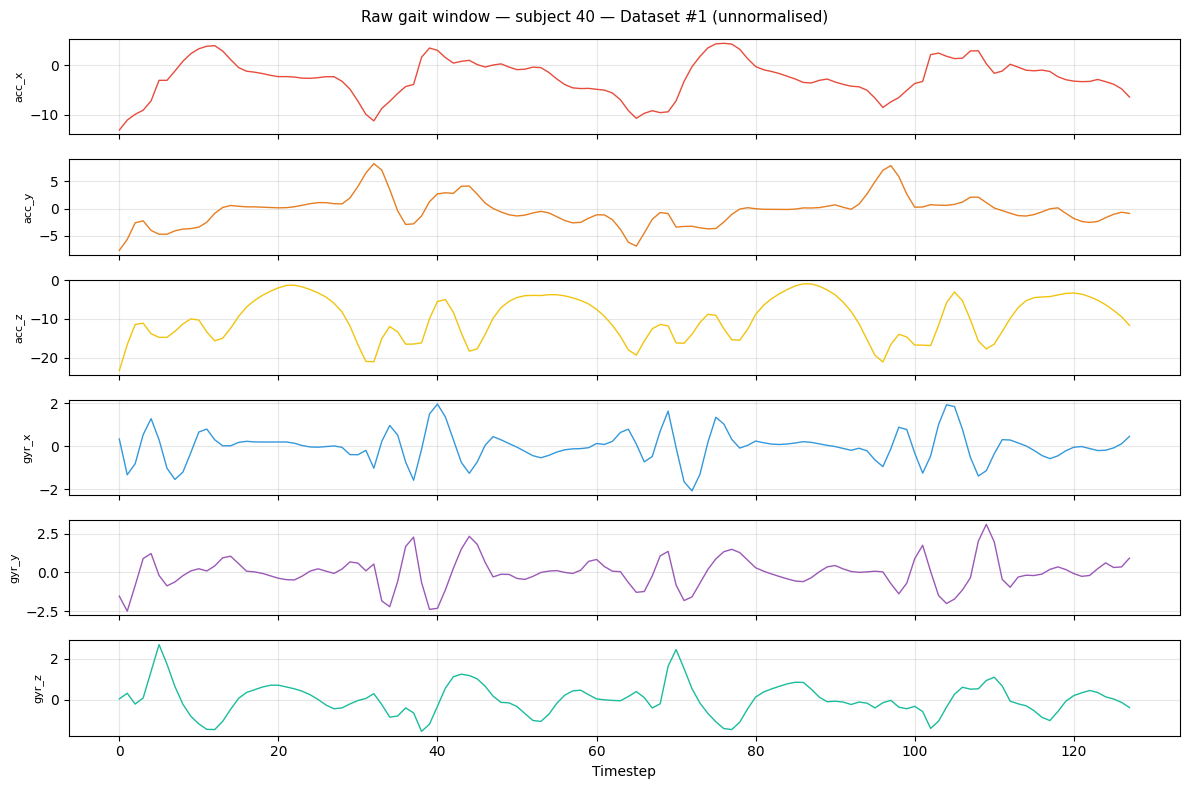

Figure saved: results/01_raw_window.png


In [11]:
CHANNEL_NAMES = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
COLORS        = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#9b59b6', '#1abc9c']

sample_window = X_d1_train[0]   # (6, 128)
sample_label  = y_d1_train[0]

fig, axes = plt.subplots(6, 1, figsize=(12, 8), sharex=True)
for i, (ax, name, color) in enumerate(zip(axes, CHANNEL_NAMES, COLORS)):
    ax.plot(sample_window[i], color=color, linewidth=1)
    ax.set_ylabel(name, fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Timestep')
fig.suptitle(f'Raw gait window — subject {sample_label} — Dataset #1 (unnormalised)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_raw_window.png', dpi=150)
plt.show()
log.info('Figure saved: results/01_raw_window.png')

## 11. Wrap Up

The subject split is confirmed and saved. The code below prints a summary and writes the LaTeX metrics file.

In [12]:
summary = f"""
=== NOTEBOOK 01 SUMMARY ===

Dataset #1:  {len(y_d1_train)} train + {len(y_d1_test)} test windows  |  {len(d1_subjects)} subjects (IDs 1–118)
Dataset #2:  {len(y_d2_train)} train + {len(y_d2_test)} test windows  |  {len(d2_subjects)} subjects (IDs 1–20)
Dataset #5:  {len(y_d5_train)} train + {len(y_d5_test)} test pairs
             Train balance: {100*d5_train_same/len(y_d5_train):.1f}% same / {100*d5_train_diff/len(y_d5_train):.1f}% different
             Test  balance: {100*d5_test_same/len(y_d5_test):.1f}% same / {100*d5_test_diff/len(y_d5_test):.1f}% different

Subject split:
  Training subjects  (members, CNN + auth training): n={len(train_ids)}  IDs {min(train_ids)}..{max(train_ids)}
  Held-out subjects  (non-members, MIA test):        n={len(held_out_ids)}  IDs {held_out_ids}

Output: logs/subject_split.json  ✓
"""
print(summary)
log.info(summary)


=== NOTEBOOK 01 SUMMARY ===

Dataset #1:  33104 train + 3740 test windows  |  118 subjects (IDs 1–118)
Dataset #2:  44339 train + 4936 test windows  |  20 subjects (IDs 1–20)
Dataset #5:  66542 train + 7600 test pairs
             Train balance: 50.0% same / 50.0% different
             Test  balance: 50.0% same / 50.0% different

Subject split:
  Training subjects  (members, CNN + auth training): n=98  IDs 21..118
  Held-out subjects  (non-members, MIA test):        n=20  IDs [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

Output: logs/subject_split.json  ✓




=== NOTEBOOK 01 SUMMARY ===

Dataset #1:  33104 train + 3740 test windows  |  118 subjects (IDs 1–118)
Dataset #2:  44339 train + 4936 test windows  |  20 subjects (IDs 1–20)
Dataset #5:  66542 train + 7600 test pairs
             Train balance: 50.0% same / 50.0% different
             Test  balance: 50.0% same / 50.0% different

Subject split:
  Training subjects  (members, CNN + auth training): n=98  IDs 21..118
  Held-out subjects  (non-members, MIA test):        n=20  IDs [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

Output: logs/subject_split.json  ✓



In [13]:
# ── Write LaTeX metrics ──
import sys; sys.path.insert(0, '..')
from src.utils.latex_writer import write_latex_metrics
write_latex_metrics('nb01', {
    'doneSubjectsTotal':   len(d1_subjects),
    'doneTrainSubjects':   len(train_ids),
    'doneHeldOutSubjects': len(held_out_ids),
    'doneDoneTrainWindows': len(y_d1_train) + len(y_d1_test),
    'doneDfiveTrainPairs': len(y_d5_train),
    'doneDfiveTestPairs':  len(y_d5_test),
}, output_dir='../latex/generated', log=log)

LaTeX metrics written: ../latex/generated/nb01_metrics.tex


## Summary

The subject split is set: 98 members (IDs 21-118, Dataset #1) and 20 non-members (IDs 1-20, Dataset #2).

| Statistic | Value |
|---|---|
| Training subjects | 98 (IDs 21-118, Dataset #1) |
| Held-out subjects | 20 (IDs 1-20, Dataset #2) |
| D1 train windows | 33,104 |
| D1 test windows | 3,740 |
| D5 train pairs | 66,542 (50% same-person) |
| D5 test pairs | 7,600 (50% same-person) |

A detail worth noting: the held-out subjects come from Dataset #2, recorded in a different session from D1. This means probe queries for non-members in NB04 come from a different day than the training data. It makes the attack setup more realistic but adds a potential confound: non-members might score lower simply because cross-session authentication is harder, not because they were absent from training. NB04 includes a controlled experiment to disentangle these two effects.

The D5 dataset has a perfectly balanced 50/50 label distribution, which is part of the original dataset construction. This is convenient: with equal numbers of same-person and different-person pairs per subject, the two terms in δ = mean P(same) − mean P(diff) are estimated from similar amounts of data and the signal is easier to interpret.

The Milani WIFS 2024 paper divides the 118 subjects into four incremental tasks for continual learning. This notebook simplifies to a static two-phase setup to isolate the membership inference signal cleanly. The continual learning experiment (measuring how attack accuracy changes as subjects are added task by task) is the natural extension once the baseline results in NB01-NB05 are established.